In [1]:
# importing necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
# loading dataset
df = pd.read_csv('Amazonreviews.csv')
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
99995,99996,B000LQORDE,A2P7HIRYYWVOBD,Mason,2,5,5,1254096000,yummy!,I just love it and will buy another box when I...
99996,99997,B000LQORDE,A1K0ZH5MQFBA77,jennilight,2,5,4,1250985600,Tastes like More!,My late father in law used to have a rating sy...
99997,99998,B000LQORDE,A29FRN2O7LWINL,T. Tsai,2,5,5,1237766400,Great ramen,This is my favorite brand of Korean ramen. It ...
99998,99999,B000LQORDE,A9Q950IPXJR1D,"Lynda ""casual customer""",2,5,4,1237161600,Spicy!!,"I do like these noodles although, to say they ..."


In [3]:
# checking missing value
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               6
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   2
Text                      0
dtype: int64

In [4]:
# handling missing value
df.dropna(inplace=True)

In [5]:
# Check for duplicates
duplicates = df[df.duplicated()]

if duplicates.empty:
    print("No duplicates found")
else:
    print("Duplicates found:")
    print(duplicates)

No duplicates found


In [8]:
# Data summary

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 99992 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      99992 non-null  int64 
 1   ProductId               99992 non-null  object
 2   UserId                  99992 non-null  object
 3   ProfileName             99992 non-null  object
 4   HelpfulnessNumerator    99992 non-null  int64 
 5   HelpfulnessDenominator  99992 non-null  int64 
 6   Score                   99992 non-null  int64 
 7   Time                    99992 non-null  int64 
 8   Summary                 99992 non-null  object
 9   Text                    99992 non-null  object
 10  cleaned_text            99992 non-null  object
 11  tokenized_text          99992 non-null  object
 12  filtered_text           99992 non-null  object
 13  lemmatized_text         99992 non-null  object
 14  preprocessed_text       99992 non-null  object
dtypes: int6

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,99992.000000,99992.000000,99992.000000,99992.000000,9.999200e+04
mean,50001.356979,1.639861,2.119590,4.152692,1.296227e+09
std,28868.307257,6.369163,6.990645,1.320092,4.781896e+07
min,1.000000,0.000000,0.000000,1.000000,9.486720e+08
25%,24999.750000,0.000000,0.000000,4.000000,1.270512e+09
50%,50003.500000,0.000000,1.000000,5.000000,1.311725e+09
75%,75002.250000,2.000000,2.000000,5.000000,1.332720e+09
max,100000.000000,559.000000,562.000000,5.000000,1.351210e+09


In [9]:
df.shape

(99992, 15)

In [10]:
df.dtypes

Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
cleaned_text              object
tokenized_text            object
filtered_text             object
lemmatized_text           object
preprocessed_text         object
dtype: object

In [11]:
# Checking for outlier
# Select numeric columns from the DataFrame
numeric_columns = df.select_dtypes(include=np.number)

# Statistical methods: Interquartile Range (IQR)
Q1 = np.percentile(numeric_columns, 25)
Q3 = np.percentile(numeric_columns, 75)
IQR = Q3 - Q1


In [12]:
# Checking for outlier
# Statistical methods: Interquartile Range (IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(numeric_columns < lower_bound) | (numeric_columns > upper_bound)]
print("Outliers detected using IQR:")
print(outliers_iqr)


Outliers detected using IQR:
       Id ProductId UserId ProfileName  HelpfulnessNumerator  \
0     NaN       NaN    NaN         NaN                   NaN   
1     NaN       NaN    NaN         NaN                   NaN   
2     NaN       NaN    NaN         NaN                   NaN   
3     NaN       NaN    NaN         NaN                   NaN   
4     NaN       NaN    NaN         NaN                   NaN   
...    ..       ...    ...         ...                   ...   
99995 NaN       NaN    NaN         NaN                   NaN   
99996 NaN       NaN    NaN         NaN                   NaN   
99997 NaN       NaN    NaN         NaN                   NaN   
99998 NaN       NaN    NaN         NaN                   NaN   
99999 NaN       NaN    NaN         NaN                   NaN   

       HelpfulnessDenominator  Score        Time Summary Text cleaned_text  \
0                         NaN    NaN  1303862400     NaN  NaN          NaN   
1                         NaN    NaN  13469760

In [13]:
outliers_iqr.sum()

Id                                    0.0
ProductId                               0
UserId                                  0
ProfileName                             0
HelpfulnessNumerator                  0.0
HelpfulnessDenominator                0.0
Score                                 0.0
Time                      129612347596800
Summary                                 0
Text                                    0
cleaned_text                            0
tokenized_text                          0
filtered_text                           0
lemmatized_text                         0
preprocessed_text                       0
dtype: object

In [14]:
df.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,cleaned_text,tokenized_text,filtered_text,lemmatized_text,preprocessed_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ...","[bought, several, vitality, canned, dog, food,...","[bought, several, vitality, canned, dog, food,...",bought several vitality canned dog food produc...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,...","[product, arrived, labeled, jumbo, salted, pea...","[product, arrived, labeled, jumbo, salted, pea...",product arrived labeled jumbo salted peanutsth...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro...","[confection, around, centuries, light, pillowy...","[confection, around, century, light, pillowy, ...",confection around century light pillowy citrus...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr...","[looking, secret, ingredient, robitussin, beli...","[looking, secret, ingredient, robitussin, beli...",looking secret ingredient robitussin believe f...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide...,"[great, taffy, at, a, great, price, there, was...","[great, taffy, great, price, wide, assortment,...","[great, taffy, great, price, wide, assortment,...",great taffy great price wide assortment yummy ...


In [15]:
df['Score'].value_counts()

Score
5    62408
4    14643
1     9317
3     8059
2     5565
Name: count, dtype: int64

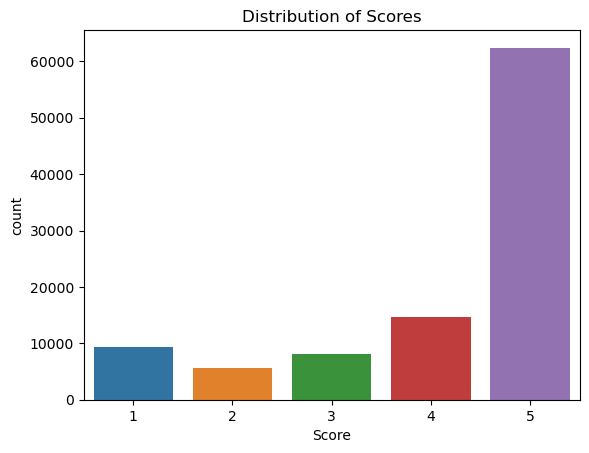

In [16]:
sns.countplot(x='Score', data=df)
plt.title('Distribution of Scores')
plt.show()

In [17]:
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Text cleaning
def clean_text(text):
    text = re.sub('<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation and special characters
    text = re.sub(r'\d+', '', text)  # Remove digits
    return text

df['cleaned_text'] = df['Text'].apply(lambda x: clean_text(x.lower()))

# Tokenization
df['tokenized_text'] = df['cleaned_text'].apply(lambda x: word_tokenize(x))

# Stopword removal
stop_words = set(stopwords.words('english'))
df['filtered_text'] = df['tokenized_text'].apply(lambda x: [word for word in x if word not in stop_words])

# Lemmatization
lemmatizer = WordNetLemmatizer()
df['lemmatized_text'] = df['filtered_text'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

# Joining tokens back into sentences
df['preprocessed_text'] = df['lemmatized_text'].apply(lambda x: ' '.join(x))


In [18]:
def summary_text(text):
    text = re.sub('<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation and special characters
    text = re.sub(r'\d+', '', text)  # Remove digits
    return text

df['summary_text'] = df['Summary'].apply(lambda x: clean_text(x.lower()))

# Tokenization
df['summary_text'] = df['summary_text'].apply(lambda x: word_tokenize(x))

# Stopword removal
stop_words = set(stopwords.words('english'))
df['summary_text'] = df['summary_text'].apply(lambda x: [word for word in x if word not in stop_words])

# Lemmatization
lemmatizer = WordNetLemmatizer()
df['summary_text'] = df['summary_text'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

# Joining tokens back into sentences
df['summary_text'] = df['summary_text'].apply(lambda x: ' '.join(x))

df


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,cleaned_text,tokenized_text,filtered_text,lemmatized_text,preprocessed_text,summary_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ...","[bought, several, vitality, canned, dog, food,...","[bought, several, vitality, canned, dog, food,...",bought several vitality canned dog food produc...,good quality dog food
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,...","[product, arrived, labeled, jumbo, salted, pea...","[product, arrived, labeled, jumbo, salted, pea...",product arrived labeled jumbo salted peanutsth...,advertised
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro...","[confection, around, centuries, light, pillowy...","[confection, around, century, light, pillowy, ...",confection around century light pillowy citrus...,delight say
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr...","[looking, secret, ingredient, robitussin, beli...","[looking, secret, ingredient, robitussin, beli...",looking secret ingredient robitussin believe f...,cough medicine
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide...,"[great, taffy, at, a, great, price, there, was...","[great, taffy, great, price, wide, assortment,...","[great, taffy, great, price, wide, assortment,...",great taffy great price wide assortment yummy ...,great taffy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,B000LQORDE,A2P7HIRYYWVOBD,Mason,2,5,5,1254096000,yummy!,I just love it and will buy another box when I...,i just love it and will buy another box when i...,"[i, just, love, it, and, will, buy, another, b...","[love, buy, another, box, im, done, last, one]","[love, buy, another, box, im, done, last, one]",love buy another box im done last one,yummy
99996,99997,B000LQORDE,A1K0ZH5MQFBA77,jennilight,2,5,4,1250985600,Tastes like More!,My late father in law used to have a rating sy...,my late father in law used to have a rating sy...,"[my, late, father, in, law, used, to, have, a,...","[late, father, law, used, rating, system, meal...","[late, father, law, used, rating, system, meal...",late father law used rating system meal partic...,taste like
99997,99998,B000LQORDE,A29FRN2O7LWINL,T. Tsai,2,5,5,1237766400,Great ramen,This is my favorite brand of Korean ramen. It ...,this is my favorite brand of korean ramen it i...,"[this, is, my, favorite, brand, of, korean, ra...","[favorite, brand, korean, ramen, spicy, used, ...","[favorite, brand, korean, ramen, spicy, used, ...",favorite brand korean ramen spicy used eating ...,great ramen
99998,99999,B000LQORDE,A9Q950IPXJR1D,"Lynda ""casual customer""",2,5,4,1237161600,Spicy!!,"I do like these noodles although, to say they ...",i do like these noodles although to say they a...,"[i, do, like, these, noodles, although, to, sa...","[like, noodles, although, say, spicy, somewhat...","[like, noodle, although, say, spicy, somewhat,...",like noodle although say spicy somewhat unders...,spicy


In [19]:
# removing relevant columns
# Select relevant columns
df = df[["ProductId",'Score', 'preprocessed_text', 'summary_text']]

df.head()

,ProductId,Score,preprocessed_text,summary_text
0,B001E4KFG0,5,bought several vitality canned dog food produc...,good quality dog food
1,B00813GRG4,1,product arrived labeled jumbo salted peanutsth...,advertised
2,B000LQOCH0,4,confection around century light pillowy citrus...,delight say
3,B000UA0QIQ,2,looking secret ingredient robitussin believe f...,cough medicine
4,B006K2ZZ7K,5,great taffy great price wide assortment yummy ...,great taffy


In [20]:
# Words to remove
words_to_remove = ["br", "s"]
# Define a lambda function to remove words
remove_words = lambda x: ' '.join([word for word in x.split() if word.lower() not in words_to_remove])

# Apply the lambda function to the 'content' column of the DataFrame

df['preprocessed_text'] = df['preprocessed_text'].apply(remove_words)


C:\Users\Hewlett Packard\AppData\Local\Temp\ipykernel_22724\1940893133.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['preprocessed_text'] = df['preprocessed_text'].apply(remove_words)


In [21]:
# to know the min and max word count of the review

# Function to count words in a review
def count_words(review):
    return len(review.split())

# Calculate min and max word counts for each review
min_max_word_counts = []
for review in df['preprocessed_text']:  # Replace 'Text_Clean' with the column containing your cleaned reviews
    word_count = count_words(review)
    min_max_word_counts.append(word_count)

# Calculate min and max word counts from the list
min_word_count = min(min_max_word_counts)
max_word_count = max(min_max_word_counts)

# Display results
print("Minimum word count:", min_word_count)
print("Maximum word count:", max_word_count)

Minimum word count: 2
Maximum word count: 1472


In [22]:
# Convert column headers to lowercase
df.columns = map(str.lower, df.columns)


In [23]:
df

,productid,score,preprocessed_text,summary_text
0,B001E4KFG0,5,bought several vitality canned dog food produc...,good quality dog food
1,B00813GRG4,1,product arrived labeled jumbo salted peanutsth...,advertised
2,B000LQOCH0,4,confection around century light pillowy citrus...,delight say
3,B000UA0QIQ,2,looking secret ingredient robitussin believe f...,cough medicine
4,B006K2ZZ7K,5,great taffy great price wide assortment yummy ...,great taffy
...,...,...,...,...
99995,B000LQORDE,5,love buy another box im done last one,yummy
99996,B000LQORDE,4,late father law used rating system meal partic...,taste like
99997,B000LQORDE,5,favorite brand korean ramen spicy used eating ...,great ramen
99998,B000LQORDE,4,like noodle although say spicy somewhat unders...,spicy


# VISUALIZATION

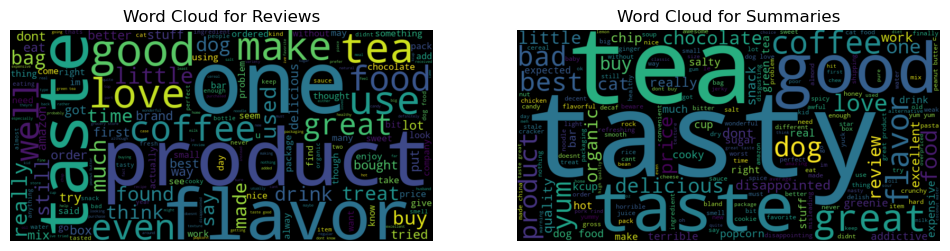

In [92]:
# word cloud visualization for reviews and summary

from wordcloud import WordCloud

# Generate word cloud for reviews
reviews_text = ' '.join(df['preprocessed_text'])
wordcloud_reviews = WordCloud(width=800, height=400).generate(reviews_text)

# Generate word cloud for summaries
summaries_text = ' '.join(df['summary_text'])
wordcloud_summaries = WordCloud(width=800, height=400).generate(summaries_text)

# Plot word clouds
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_reviews, interpolation='bilinear')
plt.title('Word Cloud for Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_summaries, interpolation='bilinear')
plt.title('Word Cloud for Summaries')
plt.axis('off')

plt.show()


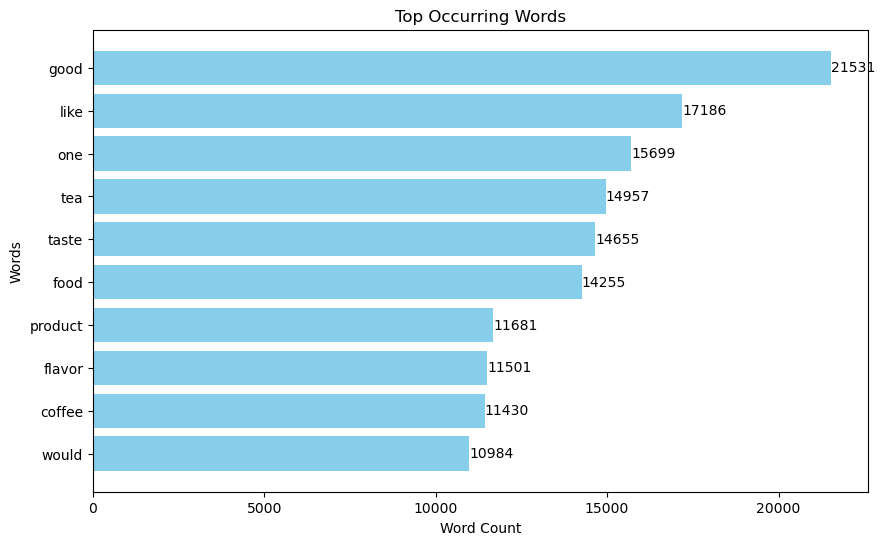

In [93]:
# Top word occurence
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Sample text data
documents = df['preprocessed_text']

# Step 1: Count word occurrences
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

# Step 2: Sum occurrences
word_counts = np.asarray(X.sum(axis=0)).ravel()

# Step 3: Sort occurrences
word_indices = np.argsort(word_counts)[::-1]

# Step 4: Select top words
top_n = 10  # Number of top words to select
top_words = [word for word, idx in vectorizer.vocabulary_.items() if idx in word_indices[:top_n]]
top_counts = word_counts[word_indices[:top_n]]

# Step 5: Visualize
plt.figure(figsize=(10, 6))
bars = plt.barh(top_words, top_counts, color='skyblue')
plt.xlabel('Word Count')
plt.ylabel('Words')
plt.title('Top Occurring Words')
plt.gca().invert_yaxis()  # Invert y-axis to have highest count at the top

# Annotate bars with counts
for bar, count in zip(bars, top_counts):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{count}', 
             va='center', ha='left', color='black')

plt.show()


In [94]:
# topic modelling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Topic Modeling (LDA)
def lda_topic_modeling(text_data, num_topics=5):
    # Vectorize text data
    vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
    X = vectorizer.fit_transform(text_data)
    
    # Fit LDA model
    lda_model = LatentDirichletAllocation(n_components=num_topics, max_iter=10, learning_method='online', random_state=42)
    lda_model.fit(X)
    
    # Print topics and associated words
    feature_names = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(lda_model.components_):
        print(f"Topic {idx+1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]))
        print()
    
    return lda_model

# Apply LDA on preprocessed text data
num_topics = 5  # Adjust the number of topics as needed
lda_model = lda_topic_modeling(df['preprocessed_text'], num_topics=num_topics)


Topic 1:
taste like sugar drink water product flavor ingredient good sweet

Topic 2:
food dog treat cat love like day time product eat

Topic 3:
product amazon good box like store price great buy order

Topic 4:
chip flavor love snack like bag chocolate salt great good

Topic 5:
tea coffee flavor taste like cup good hot chocolate make



# Topics interpretation

Topic 1: Positive opinions about products, which would suggest that customers are happy with the things they bought from Amazon or other retailers.
Topic 2: Talk about pet food and treats, with a focus on dogs, cats, and associated terminology. It also suggests having discussions about pet care and preferences.
Topic 3: Terms connected to usage and reviews, such as product, use, review, and smell, denoting conversations regarding reviews and user experiences with products.
Topic 4: Common flavours and components in snacks and desserts, such as sugar, salt, and chocolate, which prompt conversations about food preferences and tastes.
Topic 5: Items pertaining to drinks, such as tea, coffee, and flavour, which suggest conversations on tastes and preferences in beverages.

# Sentiment Analysis

In [26]:
# Performing sentiment polarity on reviews
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Download VADER lexicon if not already downloaded
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()


# Ensure 'Text' column is string type
df['preprocessed_text'] = df['preprocessed_text'].astype(str)

# Apply VADER sentiment analysis to the 'Text' column
df['sentiment_scores'] = df['preprocessed_text'].apply(lambda x: sid.polarity_scores(x))

# Extract compound scores from the sentiment scores
df['sentiment_scores'] = df['sentiment_scores'].apply(lambda x: x['compound'])


# Sentiment Categorization
def categorize_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_category'] = df['sentiment_scores'].apply(categorize_sentiment)
df



[nltk_data] Downloading package vader_lexicon to C:\Users\Hewlett
[nltk_data]     Packard\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\Hewlett Packard\AppData\Local\Temp\ipykernel_22724\256546233.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['preprocessed_text'] = df['preprocessed_text'].astype(str)
C:\Users\Hewlett Packard\AppData\Local\Temp\ipykernel_22724\256546233.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_scores'] = d

,productid,score,preprocessed_text,summary_text,sentiment_scores,sentiment_category
0,B001E4KFG0,5,bought several vitality canned dog food produc...,good quality dog food,0.9413,positive
1,B00813GRG4,1,product arrived labeled jumbo salted peanutsth...,advertised,-0.1027,negative
2,B000LQOCH0,4,confection around century light pillowy citrus...,delight say,0.8624,positive
3,B000UA0QIQ,2,looking secret ingredient robitussin believe f...,cough medicine,0.4404,positive
4,B006K2ZZ7K,5,great taffy great price wide assortment yummy ...,great taffy,0.9468,positive
...,...,...,...,...,...,...
99995,B000LQORDE,5,love buy another box im done last one,yummy,0.6369,positive
99996,B000LQORDE,4,late father law used rating system meal partic...,taste like,0.9809,positive
99997,B000LQORDE,5,favorite brand korean ramen spicy used eating ...,great ramen,0.8555,positive
99998,B000LQORDE,4,like noodle although say spicy somewhat unders...,spicy,0.6549,positive


In [27]:
# Performing sentiment polarity on reviews
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Download VADER lexicon if not already downloaded
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()


# Ensure 'Text' column is string type
df['summary_text'] = df['summary_text'].astype(str)

# Apply VADER sentiment analysis to the 'Text' column
df['sentiment_scores1'] = df['summary_text'].apply(lambda x: sid.polarity_scores(x))

# Extract compound scores from the sentiment scores
df['sentiment_scores1'] = df['sentiment_scores1'].apply(lambda x: x['compound'])


# Sentiment Categorization
def categorize_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_category1'] = df['sentiment_scores1'].apply(categorize_sentiment)
df



[nltk_data] Downloading package vader_lexicon to C:\Users\Hewlett
[nltk_data]     Packard\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\Hewlett Packard\AppData\Local\Temp\ipykernel_22724\1253935334.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['summary_text'] = df['summary_text'].astype(str)
C:\Users\Hewlett Packard\AppData\Local\Temp\ipykernel_22724\1253935334.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_scores1'] = df['summ

,productid,score,preprocessed_text,summary_text,sentiment_scores,sentiment_category,sentiment_scores1,sentiment_category1
0,B001E4KFG0,5,bought several vitality canned dog food produc...,good quality dog food,0.9413,positive,0.4404,positive
1,B00813GRG4,1,product arrived labeled jumbo salted peanutsth...,advertised,-0.1027,negative,0.0000,neutral
2,B000LQOCH0,4,confection around century light pillowy citrus...,delight say,0.8624,positive,0.5994,positive
3,B000UA0QIQ,2,looking secret ingredient robitussin believe f...,cough medicine,0.4404,positive,0.0000,neutral
4,B006K2ZZ7K,5,great taffy great price wide assortment yummy ...,great taffy,0.9468,positive,0.6249,positive
...,...,...,...,...,...,...,...,...
99995,B000LQORDE,5,love buy another box im done last one,yummy,0.6369,positive,0.5267,positive
99996,B000LQORDE,4,late father law used rating system meal partic...,taste like,0.9809,positive,0.3612,positive
99997,B000LQORDE,5,favorite brand korean ramen spicy used eating ...,great ramen,0.8555,positive,0.6249,positive
99998,B000LQORDE,4,like noodle although say spicy somewhat unders...,spicy,0.6549,positive,0.0000,neutral


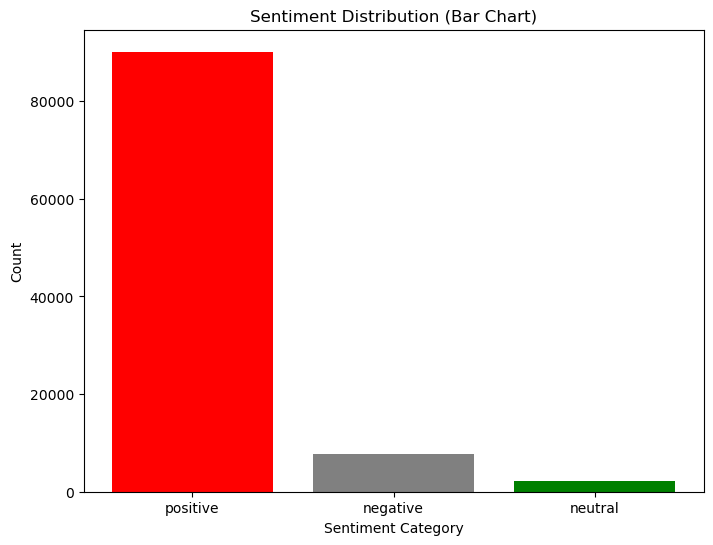

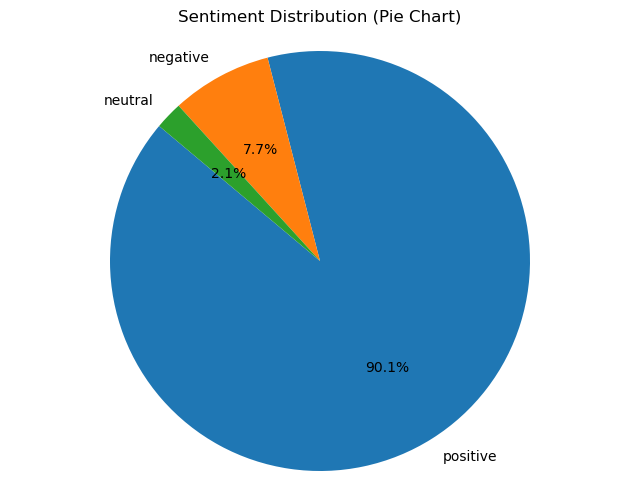

In [28]:
import matplotlib.pyplot as plt

# Calculate the number of occurrences of each sentiment category
sentiment_distribution = df['sentiment_category'].value_counts()

# Create a bar chart to show the distribution of sentiment categories
plt.figure(figsize=(8, 6))
plt.bar(sentiment_distribution.index, sentiment_distribution.values, color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution (Bar Chart)')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

# Create a pie chart to show the distribution of sentiment categories
plt.figure(figsize=(8, 6))
plt.pie(sentiment_distribution, labels=sentiment_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution (Pie Chart)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()


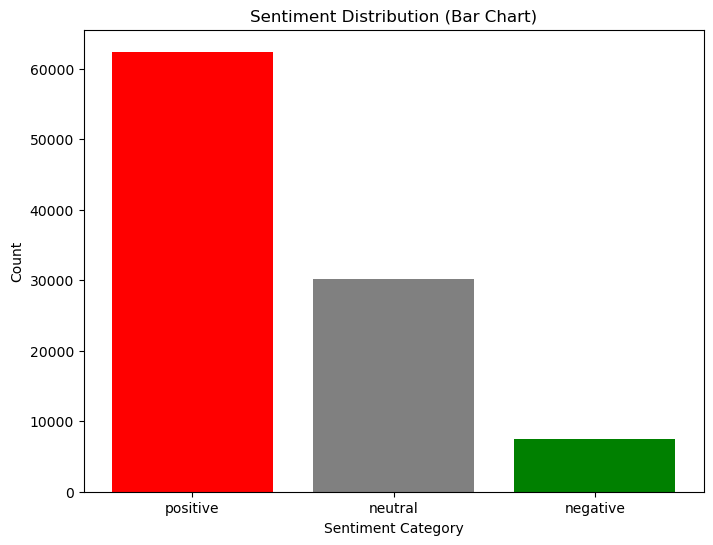

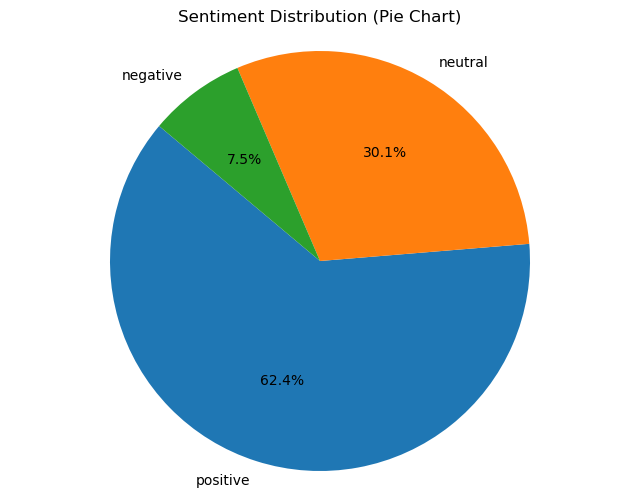

In [29]:
import matplotlib.pyplot as plt

# Calculate the number of occurrences of each sentiment category
sentiment_distribution = df['sentiment_category1'].value_counts()

# Create a bar chart to show the distribution of sentiment categories
plt.figure(figsize=(8, 6))
plt.bar(sentiment_distribution.index, sentiment_distribution.values, color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution (Bar Chart)')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

# Create a pie chart to show the distribution of sentiment categories
plt.figure(figsize=(8, 6))
plt.pie(sentiment_distribution, labels=sentiment_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution (Pie Chart)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()


In [30]:
# Sampling
from sklearn.utils import resample

# Assuming 'df' is your DataFrame containing the preprocessed text data
# Assuming 'sentiment' is the column indicating sentiment labels (e.g., 'positive', 'negative', 'neutral')

# Separate majority and minority classes
positive_reviews = df[df['sentiment_category1'] == 'positive']
negative_reviews = df[df['sentiment_category1'] == 'negative']
neutral_reviews = df[df['sentiment_category1'] == 'neutral']

# Undersample majority class (positive reviews)
undersampled_positive = resample(positive_reviews, replace=False, n_samples=len(negative_reviews), random_state=42)

# Combine undersampled positive reviews with minority classes
balanced_df = pd.concat([undersampled_positive, negative_reviews, neutral_reviews])

# Shuffle the balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=42)
balanced_df.head

<bound method NDFrame.head of         productid  score                                  preprocessed_text  \
68795  B0005ZYSIA      2  love libby pumpkin use many recipe glad shorta...   
71     B001GVISJC      5  grape gummy bear hard find area fact pretty mu...   
76074  B002EAQXQO      5  bought along chocolate chip one delicious comp...   
61383  B001EO5R04      2  purchased package tea one stash pinhead gunpow...   
10322  B003EML8PM      5  im kind addicted like hot spicy plain lowreys ...   
...           ...    ...                                                ...   
50151  B000BFRCO6      1  bought sauce local grocery store eager make pe...   
99078  B000QF90PA      1  recieved order royal brand mango suck sending ...   
77109  B001OCKIP0      3  rather ordinary granola chocolate added nice t...   
68399  B003EM7J9Q      4  love thing warm pork rind tast fresh size bag ...   
2846   B0085G4ACA      5  short brief product wonderful coconut taste pi...   

                     

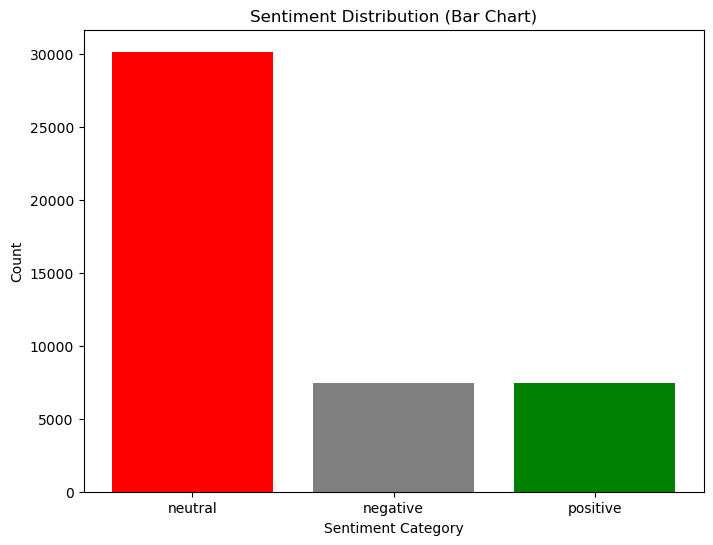

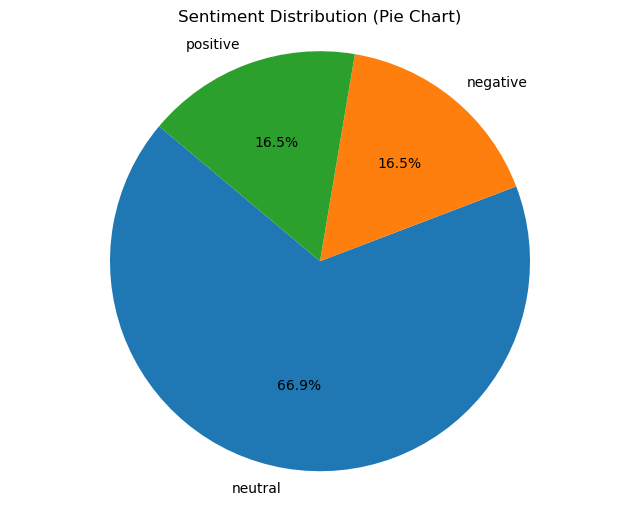

In [31]:
# distribution after sampling
import matplotlib.pyplot as plt

# Calculate the number of occurrences of each sentiment category
sentiment_distribution = balanced_df['sentiment_category1'].value_counts()

# Create a bar chart to show the distribution of sentiment categories
plt.figure(figsize=(8, 6))
plt.bar(sentiment_distribution.index, sentiment_distribution.values, color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution (Bar Chart)')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

# Create a pie chart to show the distribution of sentiment categories
plt.figure(figsize=(8, 6))
plt.pie(sentiment_distribution, labels=sentiment_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution (Pie Chart)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()


In [32]:
df = balanced_df
df

,productid,score,preprocessed_text,summary_text,sentiment_scores,sentiment_category,sentiment_scores1,sentiment_category1
68795,B0005ZYSIA,2,love libby pumpkin use many recipe glad shorta...,waay overpriced,0.7351,positive,0.0000,neutral
71,B001GVISJC,5,grape gummy bear hard find area fact pretty mu...,bigger brand,0.9568,positive,0.0000,neutral
76074,B002EAQXQO,5,bought along chocolate chip one delicious comp...,yum,0.5859,positive,0.0000,neutral
61383,B001EO5R04,2,purchased package tea one stash pinhead gunpow...,go pinhead gunpowder instead,0.9081,positive,0.0000,neutral
10322,B003EML8PM,5,im kind addicted like hot spicy plain lowreys ...,eat much,0.9819,positive,0.0000,neutral
...,...,...,...,...,...,...,...,...
50151,B000BFRCO6,1,bought sauce local grocery store eager make pe...,worst food experience ever,0.3612,positive,-0.6249,negative
99078,B000QF90PA,1,recieved order royal brand mango suck sending ...,phillipines brand,-0.4404,negative,0.0000,neutral
77109,B001OCKIP0,3,rather ordinary granola chocolate added nice t...,ordinary granola,0.9618,positive,0.0000,neutral
68399,B003EM7J9Q,4,love thing warm pork rind tast fresh size bag ...,great snack,0.8126,positive,0.6249,positive


In [97]:
# corellation coefficient between sentiment and product rating
from scipy.stats import pearsonr

# Correlate with product ratings
correlation, p_value = pearsonr(df['score'], df['sentiment_scores'])
print("Pearson correlation coefficient:", correlation)
print("P-value:", p_value)

Pearson correlation coefficient: 0.4549835452096203
P-value: 0.0


# Feature Selection & Splitting Dataset

In [33]:
from sklearn.model_selection import train_test_split

# Split the balanced dataset into features (X) and target (y)
X = df['summary_text']
y = df['sentiment_category1']  

# Split the dataset into training and testing sets (e.g., 80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (36026,) (36026,)
Testing set shape: (9007,) (9007,)


## MODEL TRAINING AND EVALUATION

# Multinomial Naive Bayes

In [34]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Assuming you have already loaded and preprocessed your data into a DataFrame called df

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["summary_text"], df["sentiment_category1"], test_size=0.2, random_state=42)

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000) 
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Model Training
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)

# Model Evaluation - Naive Bayes
y_pred = model.predict(X_test_vectorized)
print("Multinomial Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred))

# # Prediction (if you have new data)
# new_text = ["Your new text here"]
# X_new = vectorizer.transform(new_text)
# predicted_category = model.predict(X_new)
# print("Predicted Sentiment Category:", predicted_category)


Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.80      0.86      1501
     neutral       0.92      0.99      0.95      6006
    positive       0.97      0.80      0.88      1500

    accuracy                           0.93      9007
   macro avg       0.94      0.86      0.90      9007
weighted avg       0.93      0.93      0.93      9007



# Logistic Regression

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["summary_text"], df["sentiment_category1"], test_size=0.2, random_state=42)

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Step 4: Initialize Logistic Regression model
logistic_model = LogisticRegression(max_iter=5000)  # You can adjust max_iter as needed

# Model Training - Logistic Regression
logistic_model.fit(X_train_vectorized, y_train)

# Model Evaluation - Logistic Regression
logistic_y_pred = logistic_model.predict(X_test_vectorized)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, logistic_y_pred))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.82      0.89      1501
     neutral       0.94      0.99      0.97      6006
    positive       0.97      0.88      0.93      1500

    accuracy                           0.95      9007
   macro avg       0.96      0.90      0.93      9007
weighted avg       0.95      0.95      0.95      9007



# Support Vector Machine

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["summary_text"], df["sentiment_category1"], test_size=0.2, random_state=42)

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Initialize SVM model
svm_model = SVC()

# Model Training - SVM
svm_model.fit(X_train_vectorized, y_train)

# Model Evaluation - SVM
svm_y_pred = svm_model.predict(X_test_vectorized)
print("SVM Classification Report:")
print(classification_report(y_test, svm_y_pred))


SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.97      0.89      0.93      1501
     neutral       0.96      1.00      0.98      6006
    positive       0.98      0.93      0.96      1500

    accuracy                           0.97      9007
   macro avg       0.97      0.94      0.95      9007
weighted avg       0.97      0.97      0.97      9007



# Random Forest

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["summary_text"], df["sentiment_category1"], test_size=0.2, random_state=42)

# Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Initialize Random Forest model
rf_model = RandomForestClassifier()

# Model Training - Random Forest
rf_model.fit(X_train_vectorized, y_train)

# Model Evaluation - Random Forest
rf_y_pred = rf_model.predict(X_test_vectorized)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))


Random Forest Classification Report:
              precision    recall  f1-score   support

    negative       0.98      0.92      0.95      1501
     neutral       0.98      1.00      0.99      6006
    positive       0.96      0.96      0.96      1500

    accuracy                           0.98      9007
   macro avg       0.97      0.96      0.97      9007
weighted avg       0.98      0.98      0.98      9007



# Deep Learning

In [39]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


# LSTM & TCN

In [40]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from keras.preprocessing.sequence import pad_sequences

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["summary_text"], df["sentiment_category1"], test_size=0.2, random_state=42)

# Convert NumPy array to list of strings
X_train_list = [str(text) for text in X_train]
X_test_list = [str(text) for text in X_test]

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=2000)
tokenizer.fit_on_texts(X_train_list)
X_train_seq = tokenizer.texts_to_sequences(X_train_list)
X_test_seq = tokenizer.texts_to_sequences(X_test_list)
X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

# Convert Pandas Series to NumPy array
y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

# Build OneHotEncoder
encoder = OneHotEncoder()

# Fit and transform the labels for training data
y_train_encoded = encoder.fit_transform(y_train_array.reshape(-1, 1)).toarray()

# Transform the labels for testing data
y_test_encoded = encoder.transform(y_test_array.reshape(-1, 1)).toarray()

# LSTM Model
def build_lstm_model(input_dim, output_dim, input_length):
    model = Sequential()
    model.add(Embedding(input_dim, output_dim))  # Remove input_length from here
    model.add(SpatialDropout1D(0.2))
    model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2, input_shape=(input_length,)))  # Provide input_length here
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Define input dimensions
input_dim = X_train_pad.shape[1]  # Number of features
input_length = X_train_pad.shape[1]  # Number of timesteps
output_dim = 100  # Single output for binary classification

# Train LSTM model
lstm_model = build_lstm_model(input_dim, output_dim, input_length)
lstm_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.1, callbacks=[EarlyStopping(patience=3)])

# Evaluate models
lstm_preds = lstm_model.predict(X_test_pad)

# Convert predictions to binary values
lstm_preds_binary = (lstm_preds > 0.5).astype(int)

# Calculate accuracy
lstm_accuracy = accuracy_score(y_test_encoded, lstm_preds_binary)

print("LSTM Accuracy:", lstm_accuracy)


C:\Users\Hewlett Packard\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 174s 326ms/step - accuracy: 0.7408 - loss: 0.4196 - val_accuracy: 0.8662 - val_loss: 0.2676
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 117s 232ms/step - accuracy: 0.8718 - loss: 0.2572 - val_accuracy: 0.8690 - val_loss: 0.2570
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 121s 239ms/step - accuracy: 0.8742 - loss: 0.2491 - val_accuracy: 0.8673 - val_loss: 0.2603
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 116s 229ms/step - accuracy: 0.8806 - loss: 0.2387 - val_accuracy: 0.8698 - val_loss: 0.2518
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 143s 231ms/step - accuracy: 0.8756 - loss: 0.2437 - val_accuracy: 0.8701 - val_loss: 0.2520
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 119s 234ms/step - accuracy: 0.8771 - loss: 0.2417 - val_accuracy: 0.8698 - val_loss: 0.2507
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 119s 235ms/step - accuracy: 0.8805 - loss: 0.2361 - val_accuracy: 0.8701 - val_loss: 0.2520
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 143s 237ms/step - accuracy: 0.8831 -

In [46]:
from sklearn.metrics import classification_report

# Define custom class labels
target_names = ["negative", "neutral", "positive"]

# Generate classification report
classification_report_lstm = classification_report(np.argmax(y_test_encoded, axis=1), np.argmax(lstm_preds, axis=1), target_names=target_names)

print("Classification Report for LSTM Model:")
print(classification_report_lstm)


Classification Report for LSTM Model:
              precision    recall  f1-score   support

    negative       0.96      0.52      0.67      1501
     neutral       0.86      1.00      0.92      6006
    positive       0.97      0.78      0.86      1500

    accuracy                           0.88      9007
   macro avg       0.93      0.76      0.82      9007
weighted avg       0.89      0.88      0.87      9007



In [47]:
# TCN Model

import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, SpatialDropout1D, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from keras.preprocessing.sequence import pad_sequences

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df["summary_text"], df["sentiment_category1"], test_size=0.2, random_state=42)


def build_tcn_model(input_dim, output_dim, input_length):
    i = Input(shape=(input_length,))
    x = Embedding(input_dim, output_dim)(i)
    x = SpatialDropout1D(0.2)(x)
    x = Conv1D(64, 5, activation='relu', padding='same', dilation_rate=1)(x)
    x = MaxPooling1D()(x)
    x = Conv1D(128, 5, activation='relu', padding='same', dilation_rate=2)(x)
    x = MaxPooling1D()(x)
    x = Conv1D(256, 5, activation='relu', padding='same', dilation_rate=3)(x)
    x = MaxPooling1D()(x)
    x = GlobalMaxPooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(3, activation='softmax')(x)  # Adjust output dimension for multi-class classification
    model = tf.keras.Model(i, x)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])  # Use categorical_crossentropy for multi-class
    return model

# Define input dimensions
input_dim = len(tokenizer.word_index) + 1  # Adding 1 to account for 0 padding
input_length = X_train_pad.shape[1]  # Number of timesteps
output_dim = 100  # Adjust output dimension of embedding layer

# Train TCN model
tcn_model = build_tcn_model(input_dim, output_dim, input_length)
tcn_model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=64, validation_split=0.1, callbacks=[EarlyStopping(patience=3)])

# Evaluate models
tcn_preds = tcn_model.predict(X_test_pad)

# Convert predictions to class labels
tcn_preds_labels = np.argmax(tcn_preds, axis=1)

# Calculate accuracy
tcn_accuracy = accuracy_score(np.argmax(y_test_encoded, axis=1), tcn_preds_labels)

print("TCN Accuracy:", tcn_accuracy)


Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 83s 158ms/step - accuracy: 0.7736 - loss: 0.6121 - val_accuracy: 0.9473 - val_loss: 0.2069
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 72s 139ms/step - accuracy: 0.9552 - loss: 0.1708 - val_accuracy: 0.9570 - val_loss: 0.1902
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 64s 127ms/step - accuracy: 0.9674 - loss: 0.1237 - val_accuracy: 0.9600 - val_loss: 0.1785
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.9701 - loss: 0.1074 - val_accuracy: 0.9620 - val_loss: 0.1774
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.9746 - loss: 0.0937 - val_accuracy: 0.9636 - val_loss: 0.1853
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.9777 - loss: 0.0795 - val_accuracy: 0.9609 - val_loss: 0.2092
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 68s 134ms/step - accuracy: 0.9786 - loss: 0.0754 - val_accuracy: 0.9614 - val_loss: 0.2013
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
TCN Accuracy: 0.9609192850005551


In [48]:
from sklearn.metrics import classification_report

# Convert predictions to class labels
tcn_preds_labels = np.argmax(tcn_preds, axis=1)

# Define custom class labels
target_names = ["negative", "neutral", "positive"]

# Print the classification report with custom class labels
print("TCN Classification Report:")
print(classification_report(np.argmax(y_test_encoded, axis=1), tcn_preds_labels, target_names=target_names))

TCN Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.87      0.91      1501
     neutral       0.96      0.99      0.98      6006
    positive       0.97      0.92      0.95      1500

    accuracy                           0.96      9007
   macro avg       0.96      0.93      0.95      9007
weighted avg       0.96      0.96      0.96      9007



# Hybrid Model

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, SpatialDropout1D, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Convert one-hot encoded labels to class labels
y_train_labels = np.argmax(y_train_encoded, axis=1)

# Train Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(X_train_vectorized, y_train_labels)

# Make predictions using RF model on the test and training set
rf_preds_test = rf_model.predict_proba(X_test_vectorized)  # Predict probabilities for each class
rf_preds_train = rf_model.predict_proba(X_train_vectorized)

# Combine RF predictions with original features
X_train_hybrid_rf = np.hstack((X_train_pad, rf_preds_train))
X_test_hybrid_rf = np.hstack((X_test_pad, rf_preds_test))

# TCN Model
def build_tcn_model(input_dim, output_dim, input_length):
    i = Input(shape=(input_length,))
    x = Embedding(input_dim, output_dim)(i)
    x = SpatialDropout1D(0.2)(x)
    x = Conv1D(64, 5, activation='relu', padding='same', dilation_rate=1)(x)
    x = MaxPooling1D()(x)
    x = Conv1D(128, 5, activation='relu', padding='same', dilation_rate=2)(x)
    x = MaxPooling1D()(x)
    x = GlobalMaxPooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(3, activation='softmax')(x)
    model = tf.keras.Model(i, x)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Train TCN model on the hybrid features
input_length_rf = X_train_hybrid_rf.shape[1]
tcn_model_rf = build_tcn_model(input_dim=X_train_hybrid_rf.shape[1], output_dim=output_dim, input_length=input_length_rf)

# Fit the TCN model with sparse categorical cross-entropy loss
tcn_model_rf.fit(X_train_hybrid_rf, y_train_encoded, epochs=10, batch_size=64, validation_split=0.1, callbacks=[EarlyStopping(patience=3)])

# Evaluate hybrid model
tcn_preds_rf = tcn_model_rf.predict(X_test_hybrid_rf)
tcn_preds_labels_rf = np.argmax(tcn_preds_rf, axis=1)

# Convert one-hot encoded labels to class labels for y_test_encoded
y_test_multiclass = np.argmax(y_test_encoded, axis=1)

hybrid_accuracy_rf = accuracy_score(y_test_multiclass, tcn_preds_labels_rf)
print("Hybrid Model (RF) Accuracy:", hybrid_accuracy_rf)


Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.8027 - loss: 0.4987 - val_accuracy: 0.9065 - val_loss: 0.2647
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9183 - loss: 0.2409 - val_accuracy: 0.9076 - val_loss: 0.2613
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9164 - loss: 0.2390 - val_accuracy: 0.9081 - val_loss: 0.2549
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9208 - loss: 0.2268 - val_accuracy: 0.9090 - val_loss: 0.2599
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - accuracy: 0.9198 - loss: 0.2251 - val_accuracy: 0.9045 - val_loss: 0.2601
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.9218 - loss: 0.2209 - val_accuracy: 0.9070 - val_loss: 0.2625
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Hybrid Model (RF) Accuracy: 0.9074053513933608


In [50]:
from sklearn.metrics import classification_report

# Define custom class labels if needed
target_names = ["negative", "neutral", "positive"]

# Print the classification report
print("Hybrid Model (RF) Classification Report:")
print(classification_report(y_test_multiclass, tcn_preds_labels_rf, target_names=target_names))


Hybrid Model (RF) Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.70      0.79      1501
     neutral       0.90      0.98      0.94      6006
    positive       0.94      0.83      0.88      1500

    accuracy                           0.91      9007
   macro avg       0.92      0.84      0.87      9007
weighted avg       0.91      0.91      0.90      9007



# Comparing the models

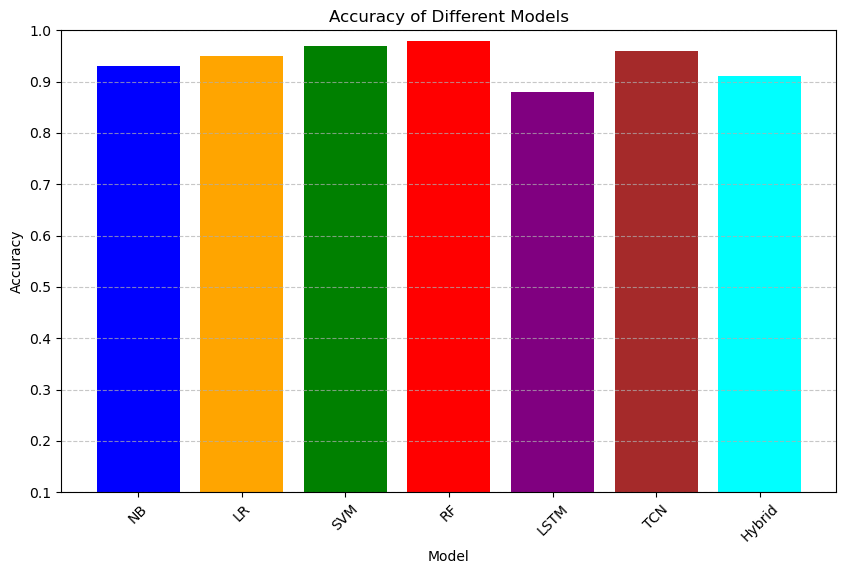

In [55]:
# Visualizing each model accuracies in bar plot

import matplotlib.pyplot as plt

# Calculate the accuracies of each model
naive_accuracy = 0.93
lr_accuracy = 0.95  
svm_accuracy = 0.97  
rf_accuracy = 0.98 
lstm_accuracy = 0.88
tcn_accuracy = 0.96  
hybrid_accuracy = 0.91 
# List of model names
models = ['NB', 'LR', 'SVM', 'RF', 'LSTM', 'TCN', 'Hybrid']

# List of accuracies
accuracies = [naive_accuracy, lr_accuracy, svm_accuracy, rf_accuracy,lstm_accuracy, tcn_accuracy, hybrid_accuracy]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'cyan'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models')
plt.ylim(0.1, 1.0)  # Set the y-axis limit for better visualization
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [57]:
# Evaluation metrics for each model
models = {
    "Multinomial Naive Bayes": {
        "accuracy": 0.93,
        "precision": {"negative": 0.92, "neutral": 0.92, "positive": 0.97},
        "recall": {"negative": 0.80, "neutral": 0.99, "positive": 0.80},
        "f1_score": {"negative": 0.86, "neutral": 0.95, "positive": 0.88}
    },
    "Logistic Regression": {
        "accuracy": 0.95,
        "precision": {"negative": 0.96, "neutral": 0.94, "positive": 0.97},
        "recall": {"negative": 0.82, "neutral": 0.99, "positive": 0.88},
        "f1_score": {"negative": 0.89, "neutral": 0.97, "positive": 0.93}
    },
    "SVM": {
        "accuracy": 0.97,
        "precision": {"negative": 0.97, "neutral": 0.96, "positive": 0.98},
        "recall": {"negative": 0.89, "neutral": 1.00, "positive": 0.93},
        "f1_score": {"negative": 0.93, "neutral": 0.98, "positive": 0.96}
    },
    "Random Forest": {
        "accuracy": 0.98,
        "precision": {"negative": 0.98, "neutral": 0.98, "positive": 0.96},
        "recall": {"negative": 0.92, "neutral": 1.00, "positive": 0.96},
        "f1_score": {"negative": 0.95, "neutral": 0.99, "positive": 0.96}
    },
    "LSTM": {
        "accuracy": 0.88,
        "precision": {"negative": 0.96, "neutral": 0.86, "positive": 0.97},
        "recall": {"negative": 0.52, "neutral": 1.00, "positive": 0.78},
        "f1_score": {"negative": 0.67, "neutral": 0.92, "positive": 0.86}
    },
    "TCN": {
        "accuracy": 0.96,
        "precision": {"negative": 0.96, "neutral": 0.96, "positive": 0.97},
        "recall": {"negative": 0.87, "neutral": 0.99, "positive": 0.92},
        "f1_score": {"negative": 0.91, "neutral": 0.98, "positive": 0.95}
    },
    "Hybrid Model (RF)": {
        "accuracy": 0.91,
        "precision": {"negative": 0.91, "neutral": 0.90, "positive": 0.94},
        "recall": {"negative": 0.70, "neutral": 0.98, "positive": 0.83},
        "f1_score": {"negative": 0.79, "neutral": 0.94, "positive": 0.88}
    }
}

# Calculate overall accuracy
for model, metrics in models.items():
    accuracy = metrics["accuracy"]
    print(f"{model}: Overall Accuracy = {accuracy}")

# Rank the models based on overall accuracy
sorted_models = sorted(models.items(), key=lambda x: x[1]["accuracy"], reverse=True)
print("\nRanked Models based on Overall Accuracy:")
for rank, (model, metrics) in enumerate(sorted_models, start=1):
    print(f"{rank}. {model}")

# Additional analysis can be done using precision, recall, and F1-score metrics.


Multinomial Naive Bayes: Overall Accuracy = 0.93
Logistic Regression: Overall Accuracy = 0.95
SVM: Overall Accuracy = 0.97
Random Forest: Overall Accuracy = 0.98
LSTM: Overall Accuracy = 0.88
TCN: Overall Accuracy = 0.96
Hybrid Model (RF): Overall Accuracy = 0.91

Ranked Models based on Overall Accuracy:
1. Random Forest
2. SVM
3. TCN
4. Logistic Regression
5. Multinomial Naive Bayes
6. Hybrid Model (RF)
7. LSTM


In [58]:
# Initialize dictionaries to store mean scores for each metric
mean_precision = {}
mean_recall = {}
mean_f1_score = {}

# Calculate mean precision, recall, and F1-score for each model
for model, metrics in models.items():
    mean_precision[model] = sum(metrics["precision"].values()) / len(metrics["precision"])
    mean_recall[model] = sum(metrics["recall"].values()) / len(metrics["recall"])
    mean_f1_score[model] = sum(metrics["f1_score"].values()) / len(metrics["f1_score"])

# Rank models based on mean precision
sorted_precision = sorted(mean_precision.items(), key=lambda x: x[1], reverse=True)
print("\nRanked Models based on Mean Precision:")
for rank, (model, score) in enumerate(sorted_precision, start=1):
    print(f"{rank}. {model}: Mean Precision = {score:.2f}")

# Rank models based on mean recall
sorted_recall = sorted(mean_recall.items(), key=lambda x: x[1], reverse=True)
print("\nRanked Models based on Mean Recall:")
for rank, (model, score) in enumerate(sorted_recall, start=1):
    print(f"{rank}. {model}: Mean Recall = {score:.2f}")

# Rank models based on mean F1-score
sorted_f1_score = sorted(mean_f1_score.items(), key=lambda x: x[1], reverse=True)
print("\nRanked Models based on Mean F1-score:")
for rank, (model, score) in enumerate(sorted_f1_score, start=1):
    print(f"{rank}. {model}: Mean F1-score = {score:.2f}")



Ranked Models based on Mean Precision:
1. Random Forest: Mean Precision = 0.97
2. SVM: Mean Precision = 0.97
3. TCN: Mean Precision = 0.96
4. Logistic Regression: Mean Precision = 0.96
5. Multinomial Naive Bayes: Mean Precision = 0.94
6. LSTM: Mean Precision = 0.93
7. Hybrid Model (RF): Mean Precision = 0.92

Ranked Models based on Mean Recall:
1. Random Forest: Mean Recall = 0.96
2. SVM: Mean Recall = 0.94
3. TCN: Mean Recall = 0.93
4. Logistic Regression: Mean Recall = 0.90
5. Multinomial Naive Bayes: Mean Recall = 0.86
6. Hybrid Model (RF): Mean Recall = 0.84
7. LSTM: Mean Recall = 0.77

Ranked Models based on Mean F1-score:
1. Random Forest: Mean F1-score = 0.97
2. SVM: Mean F1-score = 0.96
3. TCN: Mean F1-score = 0.95
4. Logistic Regression: Mean F1-score = 0.93
5. Multinomial Naive Bayes: Mean F1-score = 0.90
6. Hybrid Model (RF): Mean F1-score = 0.87
7. LSTM: Mean F1-score = 0.82


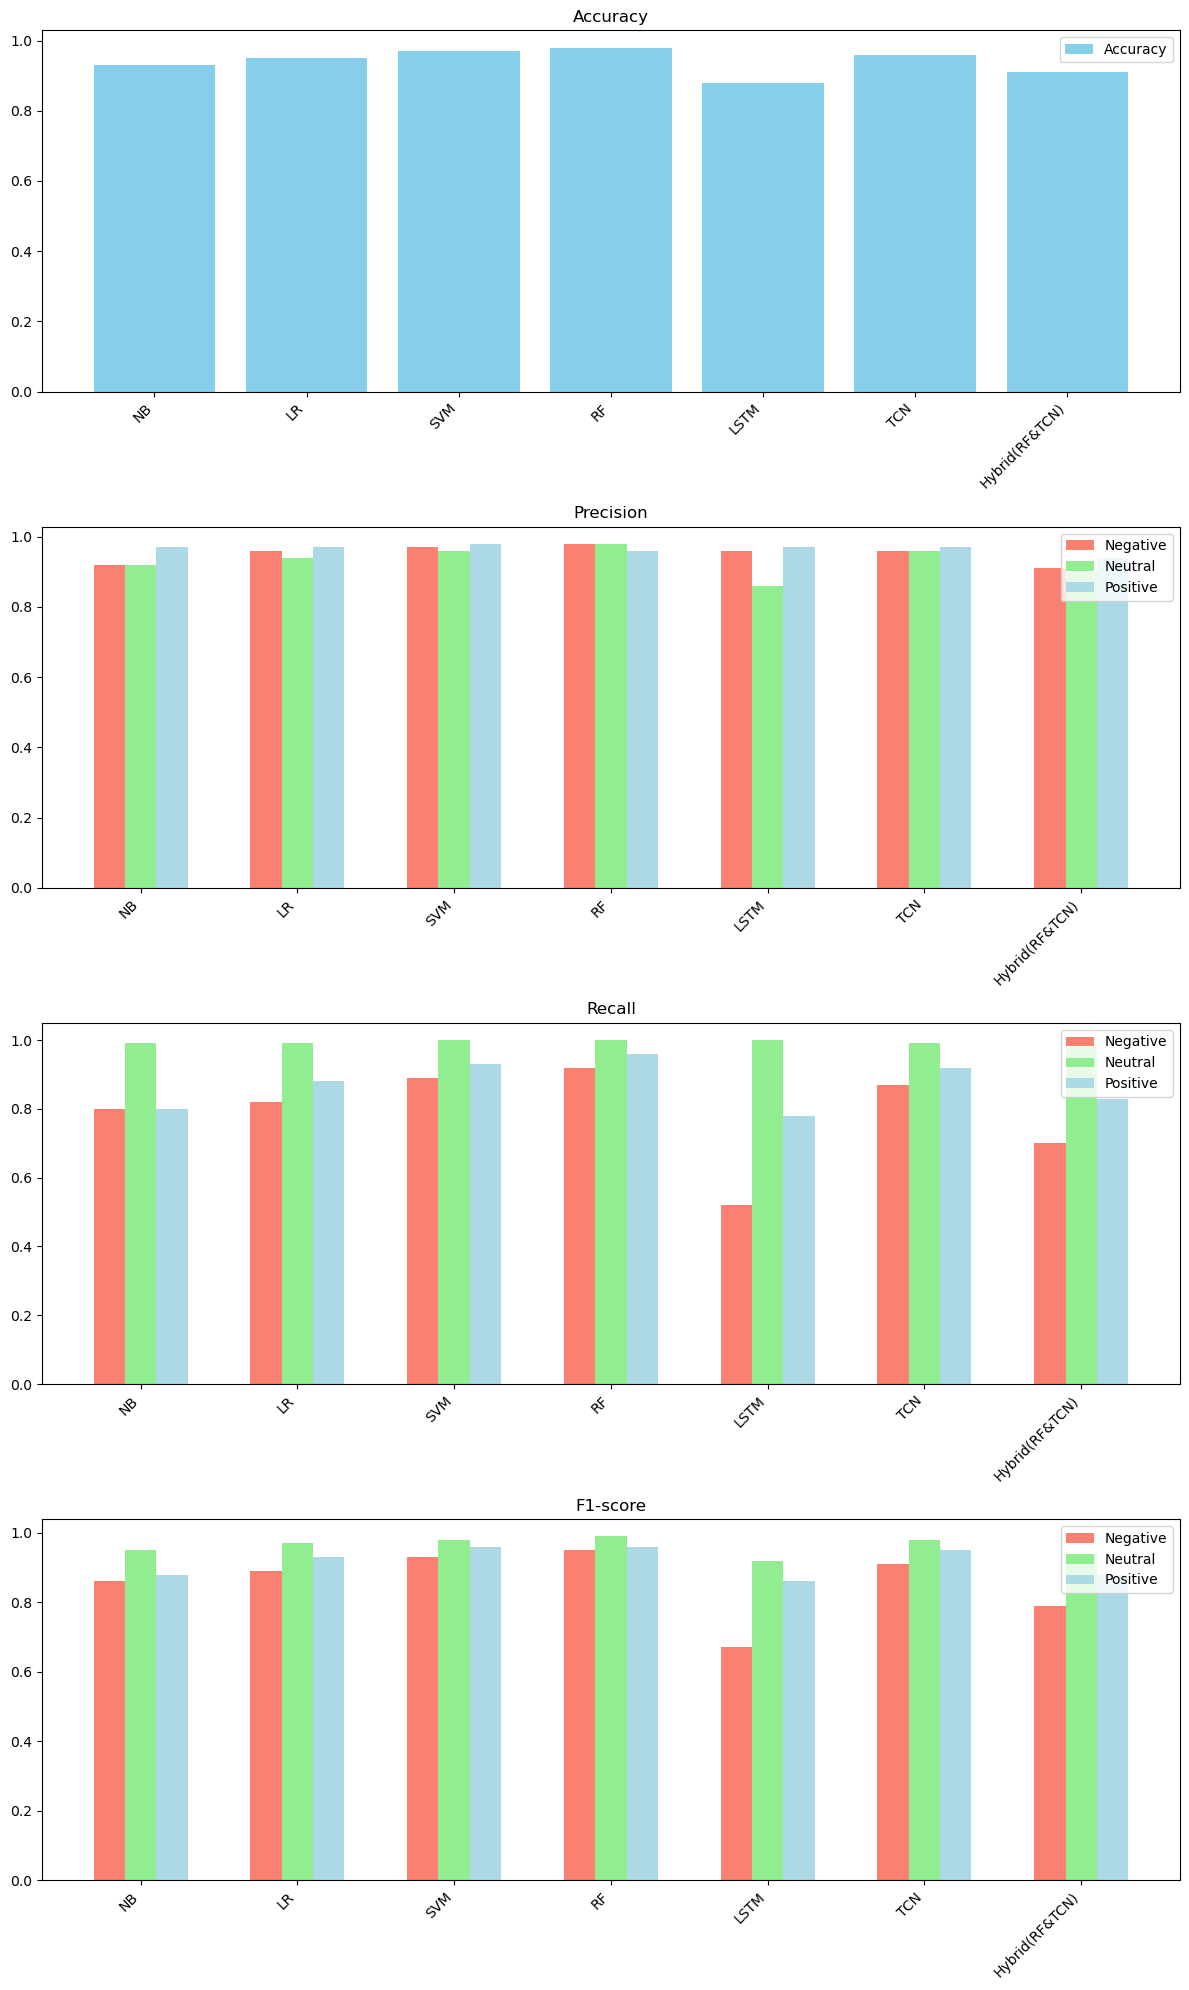

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluation metrics data
models = ['NB', 'LR', 'SVM', 'RF', 'LSTM', 'TCN', 'Hybrid(RF&TCN)']

# Accuracy data
accuracy = [0.93, 0.95, 0.97, 0.98, 0.88, 0.96, 0.91]

# Precision data
precision_negative = [0.92, 0.96, 0.97, 0.98, 0.96, 0.96, 0.91]
precision_neutral = [0.92, 0.94, 0.96, 0.98, 0.86, 0.96, 0.90]
precision_positive = [0.97, 0.97, 0.98, 0.96, 0.97, 0.97, 0.94]

# Recall data
recall_negative = [0.80, 0.82, 0.89, 0.92, 0.52, 0.87, 0.70]
recall_neutral = [0.99, 0.99, 1.00, 1.00, 1.00, 0.99, 0.98]
recall_positive = [0.80, 0.88, 0.93, 0.96, 0.78, 0.92, 0.83]

# F1-score data
f1_score_negative = [0.86, 0.89, 0.93, 0.95, 0.67, 0.91, 0.79]
f1_score_neutral = [0.95, 0.97, 0.98, 0.99, 0.92, 0.98, 0.94]
f1_score_positive = [0.88, 0.93, 0.96, 0.96, 0.86, 0.95, 0.88]

# Number of models
num_models = len(models)

# Model index
x = np.arange(num_models)

# Bar width
bar_width = 0.2

# Create grouped bar plots for each evaluation metric
fig, axs = plt.subplots(4, 1, figsize=(12, 20))

# Accuracy
axs[0].bar(x, accuracy, color='skyblue', label='Accuracy')
axs[0].set_title('Accuracy')
axs[0].set_xticks(x)
axs[0].set_xticklabels(models, rotation=45, ha='right')
axs[0].legend()

# Precision
axs[1].bar(x - bar_width, precision_negative, bar_width, color='salmon', label='Negative')
axs[1].bar(x, precision_neutral, bar_width, color='lightgreen', label='Neutral')
axs[1].bar(x + bar_width, precision_positive, bar_width, color='lightblue', label='Positive')
axs[1].set_title('Precision')
axs[1].set_xticks(x)
axs[1].set_xticklabels(models, rotation=45, ha='right')
axs[1].legend()

# Recall
axs[2].bar(x - bar_width, recall_negative, bar_width, color='salmon', label='Negative')
axs[2].bar(x, recall_neutral, bar_width, color='lightgreen', label='Neutral')
axs[2].bar(x + bar_width, recall_positive, bar_width, color='lightblue', label='Positive')
axs[2].set_title('Recall')
axs[2].set_xticks(x)
axs[2].set_xticklabels(models, rotation=45, ha='right')
axs[2].legend()

# F1-score
axs[3].bar(x - bar_width, f1_score_negative, bar_width, color='salmon', label='Negative')
axs[3].bar(x, f1_score_neutral, bar_width, color='lightgreen', label='Neutral')
axs[3].bar(x + bar_width, f1_score_positive, bar_width, color='lightblue', label='Positive')
axs[3].set_title('F1-score')
axs[3].set_xticks(x)
axs[3].set_xticklabels(models, rotation=45, ha='right')
axs[3].legend()

plt.tight_layout()
plt.show()


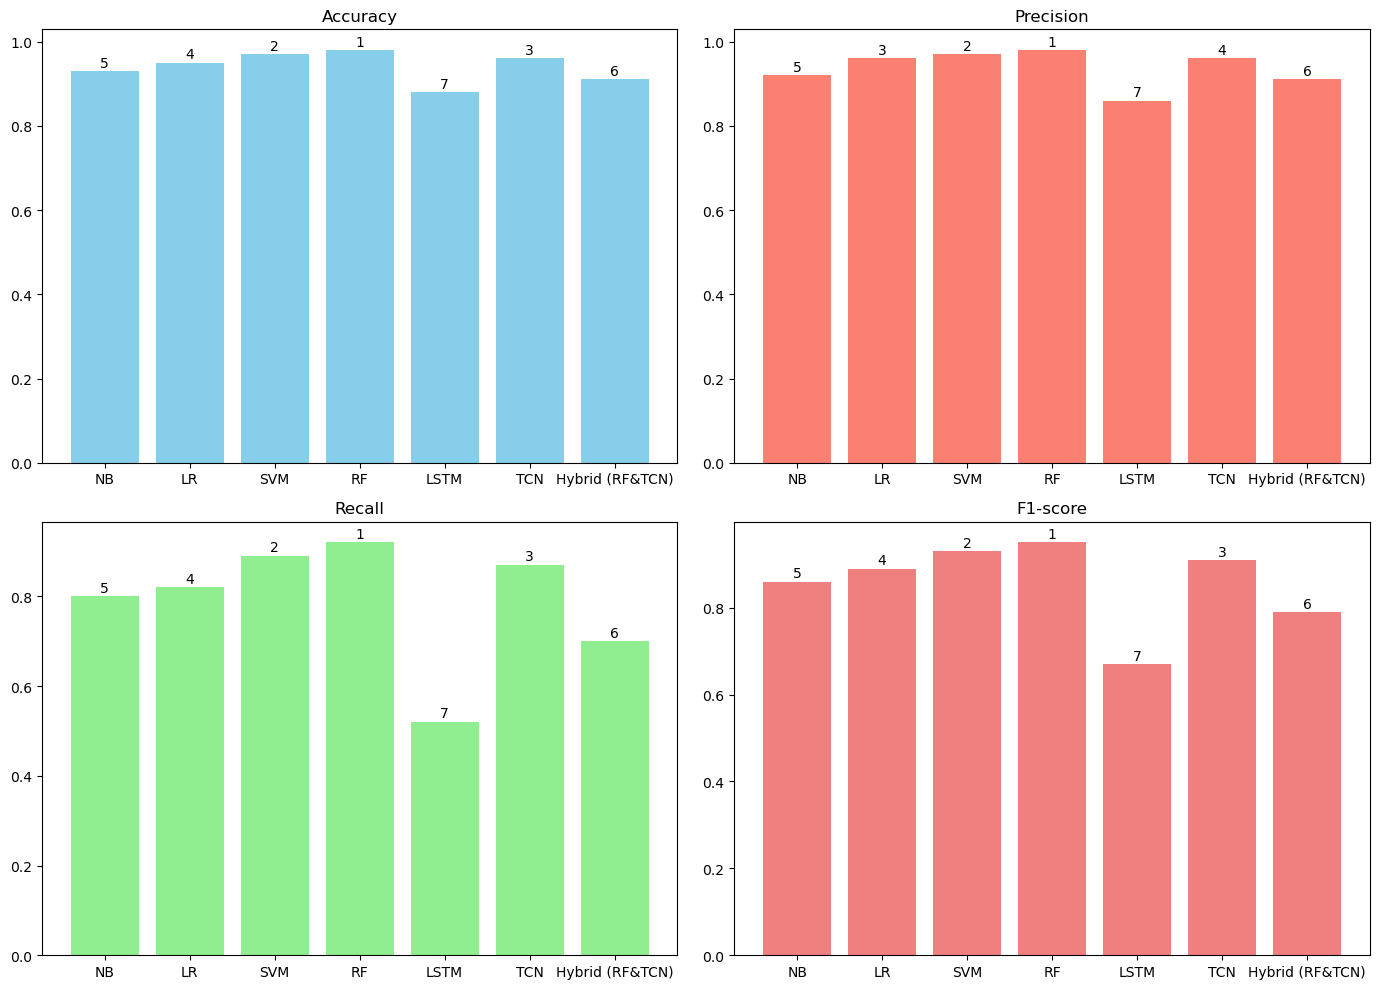

In [80]:
import matplotlib.pyplot as plt

# Evaluation metrics for each model
models = ['NB', 'LR', 'SVM', 'RF', 'LSTM', 'TCN', 'Hybrid (RF&TCN)']

# Accuracy data
accuracy = [0.93, 0.95, 0.97, 0.98, 0.88, 0.96, 0.91]

# Precision data
precision = [0.92, 0.96, 0.97, 0.98, 0.86, 0.96, 0.91]

# Recall data
recall = [0.80, 0.82, 0.89, 0.92, 0.52, 0.87, 0.70]

# F1-score data
f1_score = [0.86, 0.89, 0.93, 0.95, 0.67, 0.91, 0.79]

# Rank each model based on each evaluation metric
accuracy_rank = sorted(range(len(accuracy)), key=lambda i: accuracy[i], reverse=True)
precision_rank = sorted(range(len(precision)), key=lambda i: precision[i], reverse=True)
recall_rank = sorted(range(len(recall)), key=lambda i: recall[i], reverse=True)
f1_score_rank = sorted(range(len(f1_score)), key=lambda i: f1_score[i], reverse=True)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(models, accuracy, color='skyblue')
axes[0, 0].set_title('Accuracy')
for i, v in enumerate(accuracy):
    axes[0, 0].text(i, v + 0.01, f"{accuracy_rank.index(i)+1}", ha='center')

# Precision
axes[0, 1].bar(models, precision, color='salmon')
axes[0, 1].set_title('Precision')
for i, v in enumerate(precision):
    axes[0, 1].text(i, v + 0.01, f"{precision_rank.index(i)+1}", ha='center')

# Recall
axes[1, 0].bar(models, recall, color='lightgreen')
axes[1, 0].set_title('Recall')
for i, v in enumerate(recall):
    axes[1, 0].text(i, v + 0.01, f"{recall_rank.index(i)+1}", ha='center')

# F1-score125
axes[1, 1].bar(models, f1_score, color='lightcoral')
axes[1, 1].set_title('F1-score')
for i, v in enumerate(f1_score):
    axes[1, 1].text(i, v + 0.01, f"{f1_score_rank.index(i)+1}", ha='center')

plt.tight_layout()
plt.show()

In [86]:
import numpy as np

# Data from classification reports
models = ["Multinomial NB", "Logistic Regression", "SVM", "Random Forest", "LSTM", "TCN", "Hybrid Model (RF)"]

precision_scores = [
    [0.92, 0.92, 0.97],
    [0.96, 0.94, 0.97],
    [0.97, 0.96, 0.98],
    [0.98, 0.98, 0.96],
    [0.96, 0.86, 0.97],
    [0.96, 0.96, 0.97],
    [0.91, 0.90, 0.94]
]

recall_scores = [
    [0.80, 0.99, 0.80],
    [0.82, 0.99, 0.88],
    [0.89, 1.00, 0.93],
    [0.92, 1.00, 0.96],
    [0.52, 1.00, 0.78],
    [0.87, 0.99, 0.92],
    [0.70, 0.98, 0.83]
]

f1_scores = [
    [0.86, 0.95, 0.88],
    [0.89, 0.97, 0.93],
    [0.93, 0.98, 0.96],
    [0.95, 0.99, 0.96],
    [0.67, 0.92, 0.86],
    [0.91, 0.98, 0.95],
    [0.79, 0.94, 0.88]
]

# Convert lists to numpy arrays for easy averaging
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
f1_scores = np.array(f1_scores)

# Calculate average scores for each model
average_precisions = np.mean(precision_scores, axis=1)
average_recalls = np.mean(recall_scores, axis=1)
average_f1s = np.mean(f1_scores, axis=1)

# Calculate overall average score for each model
average_scores = (average_precisions + average_recalls + average_f1s) / 3

# Find the best model
best_model_index = np.argmax(average_scores)
best_model = models[best_model_index]

# Print the results
for i, model in enumerate(models):
    print(f"{model}:")
    print(f"  Average Precision: {average_precisions[i]:.2f}")
    print(f"  Average Recall: {average_recalls[i]:.2f}")
    print(f"  Average F1-Score: {average_f1s[i]:.2f}")
    print(f"  Overall Average Score: {average_scores[i]:.2f}")
    print()

print(f"The best model is {best_model} with an overall average score of {average_scores[best_model_index]:.2f}")


Multinomial NB:
  Average Precision: 0.94
  Average Recall: 0.86
  Average F1-Score: 0.90
  Overall Average Score: 0.90

Logistic Regression:
  Average Precision: 0.96
  Average Recall: 0.90
  Average F1-Score: 0.93
  Overall Average Score: 0.93

SVM:
  Average Precision: 0.97
  Average Recall: 0.94
  Average F1-Score: 0.96
  Overall Average Score: 0.96

Random Forest:
  Average Precision: 0.97
  Average Recall: 0.96
  Average F1-Score: 0.97
  Overall Average Score: 0.97

LSTM:
  Average Precision: 0.93
  Average Recall: 0.77
  Average F1-Score: 0.82
  Overall Average Score: 0.84

TCN:
  Average Precision: 0.96
  Average Recall: 0.93
  Average F1-Score: 0.95
  Overall Average Score: 0.95

Hybrid Model (RF):
  Average Precision: 0.92
  Average Recall: 0.84
  Average F1-Score: 0.87
  Overall Average Score: 0.87

The best model is Random Forest with an overall average score of 0.97


In [90]:
import numpy as np

# Data from classification reports
models = ["Multinomial NB", "Logistic Regression", "SVM", "Random Forest", "LSTM", "TCN", "Hybrid Model (RF)"]

precision_scores = [
    [0.92, 0.92, 0.97],
    [0.96, 0.94, 0.97],
    [0.97, 0.96, 0.98],
    [0.98, 0.98, 0.96],
    [0.96, 0.86, 0.97],
    [0.96, 0.96, 0.97],
    [0.91, 0.90, 0.94]
]

recall_scores = [
    [0.80, 0.99, 0.80],
    [0.82, 0.99, 0.88],
    [0.89, 1.00, 0.93],
    [0.92, 1.00, 0.96],
    [0.52, 1.00, 0.78],
    [0.87, 0.99, 0.92],
    [0.70, 0.98, 0.83]
]

f1_scores = [
    [0.86, 0.95, 0.88],
    [0.89, 0.97, 0.93],
    [0.93, 0.98, 0.96],
    [0.95, 0.99, 0.96],
    [0.67, 0.92, 0.86],
    [0.91, 0.98, 0.95],
    [0.79, 0.94, 0.88]
]

# Convert lists to numpy arrays for easy averaging
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
f1_scores = np.array(f1_scores)

# Calculate average scores for each model
average_precisions = np.mean(precision_scores, axis=1)
average_recalls = np.mean(recall_scores, axis=1)
average_f1s = np.mean(f1_scores, axis=1)

# Calculate overall average score for each model
average_scores = (average_precisions + average_recalls + average_f1s) / 3

# Create a list of (model, average_score) tuples
model_scores = list(zip(models, average_scores))

# Sort the models by average score in descending order
model_scores.sort(key=lambda x: x[1], reverse=True)

# Print the ranking of models
print("Model Ranking based on Overall Average Score:")
for rank, (model, score) in enumerate(model_scores, start=1):
    print(f"{rank}. {model} - Overall Average Score: {score:.2f}")
print(f"The best model is {best_model} with an overall average score of {average_scores[best_model_index]:.2f}")


Model Ranking based on Overall Average Score:
1. Random Forest - Overall Average Score: 0.97
2. SVM - Overall Average Score: 0.96
3. TCN - Overall Average Score: 0.95
4. Logistic Regression - Overall Average Score: 0.93
5. Multinomial NB - Overall Average Score: 0.90
6. Hybrid Model (RF) - Overall Average Score: 0.87
7. LSTM - Overall Average Score: 0.84
The best model is Random Forest with an overall average score of 0.97
